# Univariate Resemblance Analysis (URA) Dataset A
In this notebook the univariate resemblance analysis of Dataset A is performed for all STDG approaches.

In [2]:
#import libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
print('Libraries imported!!')

Libraries imported!!


In [3]:
#define directory of functions and actual directory
FUNCTIONS_HOME = '../../../functions/evaluation_functions/' #home directory of the project
REAL_DATA_HOME = '../../../data/raw/rembrandt/' #home directory of the project
SYN_DATA_HOME  = '../../../data/processed/rembrandt/' #home directory of the project
FUNCTIONS_DIR = 'EVALUATION FUNCTIONS/RESEMBLANCE'
ACTUAL_DIR = os.getcwd()

#change directory to functions directory
os.chdir(FUNCTIONS_HOME + FUNCTIONS_DIR)
from univariate_resemblance import basic_stats
from univariate_resemblance import student_t_tests
from univariate_resemblance import mann_whitney_tests
from univariate_resemblance import ks_tests
from univariate_resemblance import chi_squared_tests
from univariate_resemblance import scale_data
from univariate_resemblance import mahalanobis_distances
from univariate_resemblance import cosine_distances
from univariate_resemblance import js_distances
from univariate_resemblance import wass_distances

#change directory to actual directory
os.chdir(ACTUAL_DIR)
print('Functions imported!!')

Functions imported!!


## 1. Read real and synthetic datasets
In this part real and synthetic datasets are read.

In [4]:
#Define global variables
DATA_TYPES = ['Real','GM','SDV','CTGAN','WGANGP', 'ECDF']
SYNTHESIZERS = ['GM','SDV','CTGAN','WGANGP', 'ECDF']
FILEPATHS = {'Real' : REAL_DATA_HOME + '0_Depression_Data_Real_Train.csv',
            'GM' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_GM.csv',
            'SDV' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_SDV.csv',
            'CTGAN' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_CTGAN.csv',
            'WGANGP' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_WGANGP.csv',
            'ECDF' : SYN_DATA_HOME + '0_Depression_Data_Synthetic_ECDF.csv'}
categorical_columns = ['group']
data = dict()

In [5]:
#iterate over all datasets filepaths and read each dataset
for name, path in FILEPATHS.items() :
    data[name] = pd.read_csv(path)
    for col in categorical_columns :
        data[name][col] = data[name][col].astype('category')
    data[name] = data[name].iloc[0:16281,:]
data

{'Real':        group       ma1     hars1       ma2     hars2       ma3     hars3  \
 0    Control -0.872369 -0.943320 -0.872369 -0.943320 -0.872369 -1.130271   
 1   Remitted  0.628481  0.926183 -0.309550 -0.569420  0.816087 -0.569420   
 2   Remitted -0.121944 -0.195519 -0.872369 -0.756370 -0.497156 -0.008569   
 3   Remitted  0.816087  0.739233 -0.309550 -0.569420 -0.121944  0.739233   
 4   Remitted  1.003693  2.047885  0.253268  2.234835  0.628481  1.487034   
 ..       ...       ...       ...       ...       ...       ...       ...   
 91   Control -0.872369 -0.382469 -0.309550  0.178382 -0.684762 -0.756370   
 92   Control -0.872369 -0.569420 -0.684762 -0.195519 -0.872369 -0.756370   
 93   Control -0.684762 -0.943320 -0.684762 -0.756370 -0.497156 -0.943320   
 94   Control -0.684762 -0.756370 -0.872369 -0.756370 -0.872369 -0.943320   
 95  Remitted -0.684762 -0.569420 -0.309550 -0.756370 -0.121944 -0.008569   
 
          ma4     hars4       ma5  ...      ma10    hars10      ma

## 2. Basic statistics comparisson
In this part the basic statistics of each attribute for each dataset are computed.
- means and stds of all variables are compared.

In [6]:
df_means_std = pd.DataFrame(index=data['Real'].select_dtypes(include=['float64','int64']).columns.tolist())
for name in DATA_TYPES :
    means_stds = basic_stats(data[name])
    means_stds.columns = [name]
    df_means_std = pd.concat([df_means_std,means_stds], axis=1)
df_means_std

,Real,GM,SDV,CTGAN,WGANGP,ECDF
ma1,-0.1395 (0.6038),-0.2258 (0.607),-0.3636 (0.3852),-0.6896 (0.5643),-0.409 (0.0921),-0.1219 (0.6296)
hars1,-0.0923 (0.8456),-0.155 (0.8398),-0.4031 (0.5763),0.2672 (1.0748),-0.7722 (0.1406),-0.0943 (0.8785)
ma2,-0.2705 (0.5143),-0.2587 (0.5943),-0.2937 (0.532),-0.2715 (0.4889),-0.6391 (0.0509),-0.29 (0.4444)
hars2,-0.2364 (0.8326),-0.2186 (1.5276),-0.4148 (0.6377),0.5234 (1.0733),-0.7028 (0.1984),-0.213 (0.8727)
ma3,0.1028 (0.9836),0.2697 (1.1416),-0.3707 (0.5333),0.043 (1.1006),-0.2708 (0.2092),0.1165 (0.9408)
hars3,0.0985 (1.0141),0.3214 (1.2204),-0.5112 (0.6105),-0.3743 (1.059),-0.7898 (0.2505),0.1609 (0.9652)
ma4,0.1106 (0.9456),0.0739 (1.0251),-0.3142 (0.581),0.8393 (1.5554),-0.3257 (0.2036),0.1047 (0.9465)
hars4,0.1102 (0.9963),0.1185 (1.0136),-0.3644 (0.6484),-0.5931 (0.9358),-0.5858 (0.1898),-0.0008 (0.9552)
ma5,0.1888 (1.158),0.4125 (1.4965),-0.3775 (0.5337),1.2504 (1.7543),-0.1 (0.3557),0.179 (1.0084)
hars5,0.1725 (1.1656),0.3748 (1.418),-0.3829 (0.713),0.4456 (1.4077),-0.6974 (0.3227),0.1024 (0.9608)


## 3. Statistical Tests
In this part some statistical tests are performed to compare variables from real and synthetic data.

### 3.1. Sudent t-test
- null hypothesis (p > 0.05): Means of real and synthetic feature are the same.
- alternative hypothesis (p < 0.05): Mean of real and synthetic feature are significantly different.

In [7]:
p_values_student = dict()
for name in SYNTHESIZERS :
    p_values_student[name] = student_t_tests(data['Real'], data[name])
df_student_test = pd.DataFrame(data=p_values_student, index=(data['Real'].select_dtypes(include=['int64','float64'])).columns)
df_student_test.to_csv('UNIVARIATE RESEMBLANCE RESULTS/student_t_tests.csv')
df_student_test

,GM,SDV,CTGAN,WGANGP,ECDF
ma1,0.324528,0.002497,6.137225e-10,2.484983e-05,0.843617
hars1,0.606620,0.003302,1.075824e-02,4.742642e-13,0.987532
ma2,0.883579,0.759161,9.890624e-01,4.564857e-11,0.778459
hars2,0.920084,0.097188,1.338046e-07,2.659569e-07,0.849647
ma3,0.279192,0.000051,6.919345e-01,3.515672e-04,0.921658
hars3,0.170379,0.000001,1.838693e-03,1.554183e-14,0.663243
ma4,0.796651,0.000235,1.223641e-04,1.658169e-05,0.965798
hars4,0.954710,0.000127,1.073035e-06,2.020940e-10,0.431688
ma5,0.248143,0.000022,1.641997e-06,2.057633e-02,0.950353
hars5,0.281627,0.000097,1.448828e-01,3.270006e-11,0.649817


### 3.2. Mann-Whitney U-Test
- null hypothesis (p > 0.05): Real feature and synthetic feature come from the same population.
- alternative hypothesis (p < 0.05): Real feature and synthetic feature does not come from the same population.

In [8]:
p_values_mann_whitnney = dict()
for name in SYNTHESIZERS :
    p_values_mann_whitnney[name] = mann_whitney_tests(data['Real'], data[name])
df_mann_whitney = pd.DataFrame(data=p_values_mann_whitnney, index=(data['Real'].select_dtypes(include=['int64','float64'])).columns)
df_mann_whitney.to_csv('UNIVARIATE RESEMBLANCE RESULTS/mann_whitnney_tests.csv')
df_mann_whitney

,GM,SDV,CTGAN,WGANGP,ECDF
ma1,0.395999,0.037939,6.074483e-10,2.965906e-02,0.936349
hars1,0.672775,0.041031,1.504090e-02,5.525037e-11,0.870349
ma2,0.722082,0.627770,6.362606e-01,9.456935e-07,0.974243
hars2,0.277478,0.222581,1.365486e-09,2.171750e-05,0.683070
ma3,0.331648,0.001679,6.937446e-01,3.989826e-01,0.697777
hars3,0.288486,0.000008,4.156599e-04,5.591933e-12,0.538889
ma4,0.771988,0.001221,1.384178e-03,8.247442e-03,0.967725
hars4,0.963730,0.000539,6.924028e-08,3.548514e-07,0.421720
ma5,0.448641,0.000424,1.433319e-06,6.352406e-01,0.612063
hars5,0.458165,0.000677,8.563133e-02,1.624792e-08,0.908735


### 3.3. Kolmogorov-Smirnov Test
- null hypothesis (p > 0.05): Real feature and synthetic feature distributions are equal.
- alternative hypothesis (p < 0.05): Real feature and synthetic feature distributions are not equal.

In [9]:
p_values_ks = dict()
for name in SYNTHESIZERS :
    p_values_ks[name] = ks_tests(data['Real'], data[name])
df_ks = pd.DataFrame(data=p_values_ks, index=(data['Real'].select_dtypes(include=['int64','float64'])).columns)
df_ks.to_csv('UNIVARIATE RESEMBLANCE RESULTS/ks_tests.csv')
df_ks

,GM,SDV,CTGAN,WGANGP,ECDF
ma1,0.343594,1.662751e-03,1.811394e-09,6.680318e-10,0.999998
hars1,0.443212,3.074306e-02,1.662751e-03,7.686867e-20,0.999545
ma2,0.012693,1.996989e-02,4.631392e-02,6.029955e-22,0.999545
hars2,0.098527,1.269273e-02,9.449738e-12,2.113772e-06,0.992547
ma3,0.192298,9.462810e-04,9.852669e-02,1.803845e-07,0.795570
hars3,0.259985,1.523178e-04,1.662751e-03,1.838283e-15,0.962075
ma4,0.343594,2.864484e-04,1.996989e-02,7.560231e-08,0.999998
hars4,0.962075,1.662751e-03,9.664553e-06,2.894383e-13,0.962075
ma5,0.343594,1.994273e-05,7.560231e-08,2.857121e-03,0.795570
hars5,0.556565,2.864484e-04,1.391424e-01,9.449738e-12,0.992547


### 3.4. Join all p-values of all tests in one unique dataset

In [10]:
tests_all_data = np.round(np.concatenate([df_student_test.values, df_mann_whitney.values, df_ks.values] , axis=1),4)
#join results of all tests
df_tests_all = pd.DataFrame(data=tests_all_data,
    index=(data['Real'].select_dtypes(include=['int64','float64'])).columns,
    columns=['GM_S','SDV_S','CTGAN_S','WGANGP_S','ECDF_S',
             'GM_M','SDV_M','CTGAN_M','WGANGP_M','ECDF_M',
             'GM_K','SDV_K','CTGAN_K','WGANGP_K','ECDF_K'])
df_tests_all.to_csv('UNIVARIATE RESEMBLANCE RESULTS/STATISTICAL_TESTS_ALL.csv')
df_tests_all

,GM_S,SDV_S,CTGAN_S,WGANGP_S,ECDF_S,GM_M,SDV_M,CTGAN_M,WGANGP_M,ECDF_M,GM_K,SDV_K,CTGAN_K,WGANGP_K,ECDF_K
ma1,0.3245,0.0025,0.0000,0.0000,0.8436,0.3960,0.0379,0.0000,0.0297,0.9363,0.3436,0.0017,0.0000,0.0000,1.0000
hars1,0.6066,0.0033,0.0108,0.0000,0.9875,0.6728,0.0410,0.0150,0.0000,0.8703,0.4432,0.0307,0.0017,0.0000,0.9995
ma2,0.8836,0.7592,0.9891,0.0000,0.7785,0.7221,0.6278,0.6363,0.0000,0.9742,0.0127,0.0200,0.0463,0.0000,0.9995
hars2,0.9201,0.0972,0.0000,0.0000,0.8496,0.2775,0.2226,0.0000,0.0000,0.6831,0.0985,0.0127,0.0000,0.0000,0.9925
ma3,0.2792,0.0001,0.6919,0.0004,0.9217,0.3316,0.0017,0.6937,0.3990,0.6978,0.1923,0.0009,0.0985,0.0000,0.7956
hars3,0.1704,0.0000,0.0018,0.0000,0.6632,0.2885,0.0000,0.0004,0.0000,0.5389,0.2600,0.0002,0.0017,0.0000,0.9621
ma4,0.7967,0.0002,0.0001,0.0000,0.9658,0.7720,0.0012,0.0014,0.0082,0.9677,0.3436,0.0003,0.0200,0.0000,1.0000
hars4,0.9547,0.0001,0.0000,0.0000,0.4317,0.9637,0.0005,0.0000,0.0000,0.4217,0.9621,0.0017,0.0000,0.0000,0.9621
ma5,0.2481,0.0000,0.0000,0.0206,0.9504,0.4486,0.0004,0.0000,0.6352,0.6121,0.3436,0.0000,0.0000,0.0029,0.7956
hars5,0.2816,0.0001,0.1449,0.0000,0.6498,0.4582,0.0007,0.0856,0.0000,0.9087,0.5566,0.0003,0.1391,0.0000,0.9925


### 3.4. Chi-Squared Test (categorical variables)
- null hypothesis (p > 0.05): There is not statistical relationship between real and synthetic feature.
- alternative hypothesis (p < 0.05): There is a statistical relationship between real and synthetic feature.

In [11]:
p_values_chi = dict()
for name in SYNTHESIZERS :
    p_values_chi[name] = chi_squared_tests(data['Real'], data[name])
df_chi = pd.DataFrame(data=p_values_chi, index=(data['Real'].select_dtypes(include=['category'])).columns)
df_chi.to_csv('UNIVARIATE RESEMBLANCE RESULTS/chi_squared_tests.csv')
df_chi

,GM,SDV,CTGAN,WGANGP,ECDF
group,0.203827,0.39682,0.194106,1.0,1.0


## 4. Distances calculation for each numerical variable
In this part some distance metrics are calculated for each numerical variable. First the data is scaled between 0 and 1.

In [12]:
#Scale the data
num_cols = (data['Real'].select_dtypes(include=['int64','float64'])).columns
scaled_data = dict()
for name in DATA_TYPES :
    scaled_data[name] = scale_data(data[name][num_cols])
scaled_data

{'Real':          ma1     hars1  ma2  hars2   ma3     hars3       ma4     hars4  \
 0   0.000000  0.058824  0.0   0.04  0.00  0.000000  0.000000  0.045455   
 1   0.666667  0.647059  0.3   0.12  0.36  0.125000  0.409091  0.181818   
 2   0.333333  0.294118  0.0   0.08  0.08  0.250000  0.181818  0.272727   
 3   0.750000  0.588235  0.3   0.12  0.16  0.416667  0.045455  0.136364   
 4   0.833333  1.000000  0.6   0.72  0.32  0.583333  0.454545  0.818182   
 ..       ...       ...  ...    ...   ...       ...       ...       ...   
 91  0.000000  0.235294  0.3   0.28  0.04  0.083333  0.000000  0.000000   
 92  0.000000  0.176471  0.1   0.20  0.00  0.083333  0.000000  0.136364   
 93  0.083333  0.058824  0.1   0.08  0.08  0.041667  0.181818  0.090909   
 94  0.083333  0.117647  0.0   0.08  0.00  0.041667  0.000000  0.272727   
 95  0.083333  0.176471  0.3   0.08  0.16  0.250000  0.136364  0.272727   
 
          ma5     hars5  ...      ma10    hars10      ma11    hars11      ma12  \
 0   0.0

### 4.1. Wasserstein distances
Minimum amount of work required to transform a vector into another vector.

In [16]:
was_dists = dict()
#calculate distances for each synthesizer
for name in SYNTHESIZERS :
    was_dists[name] = wass_distances(scaled_data['Real'], scaled_data[name])
#create dataframe with distances
df_was_dists = pd.DataFrame(data=was_dists, index=num_cols)
df_was_dists.to_csv('UNIVARIATE RESEMBLANCE RESULTS/wass_distances.csv')
df_was_dists

,GM,SDV,CTGAN,WGANGP,ECDF
ma1,0.093481,0.052970,0.061830,0.089025,0.018229
hars1,0.126514,0.062010,0.071786,0.099836,0.018995
ma2,0.084183,0.072691,0.096498,0.233771,0.033333
hars2,0.121159,0.046552,0.075876,0.259198,0.017500
ma3,0.103900,0.026922,0.113771,0.182592,0.019583
hars3,0.155246,0.042167,0.043828,0.078308,0.025174
ma4,0.123992,0.020548,0.084384,0.135013,0.028030
hars4,0.020913,0.063678,0.073846,0.078950,0.028883
ma5,0.126671,0.048768,0.224237,0.139449,0.072275
hars5,0.122705,0.068141,0.134875,0.149301,0.028549


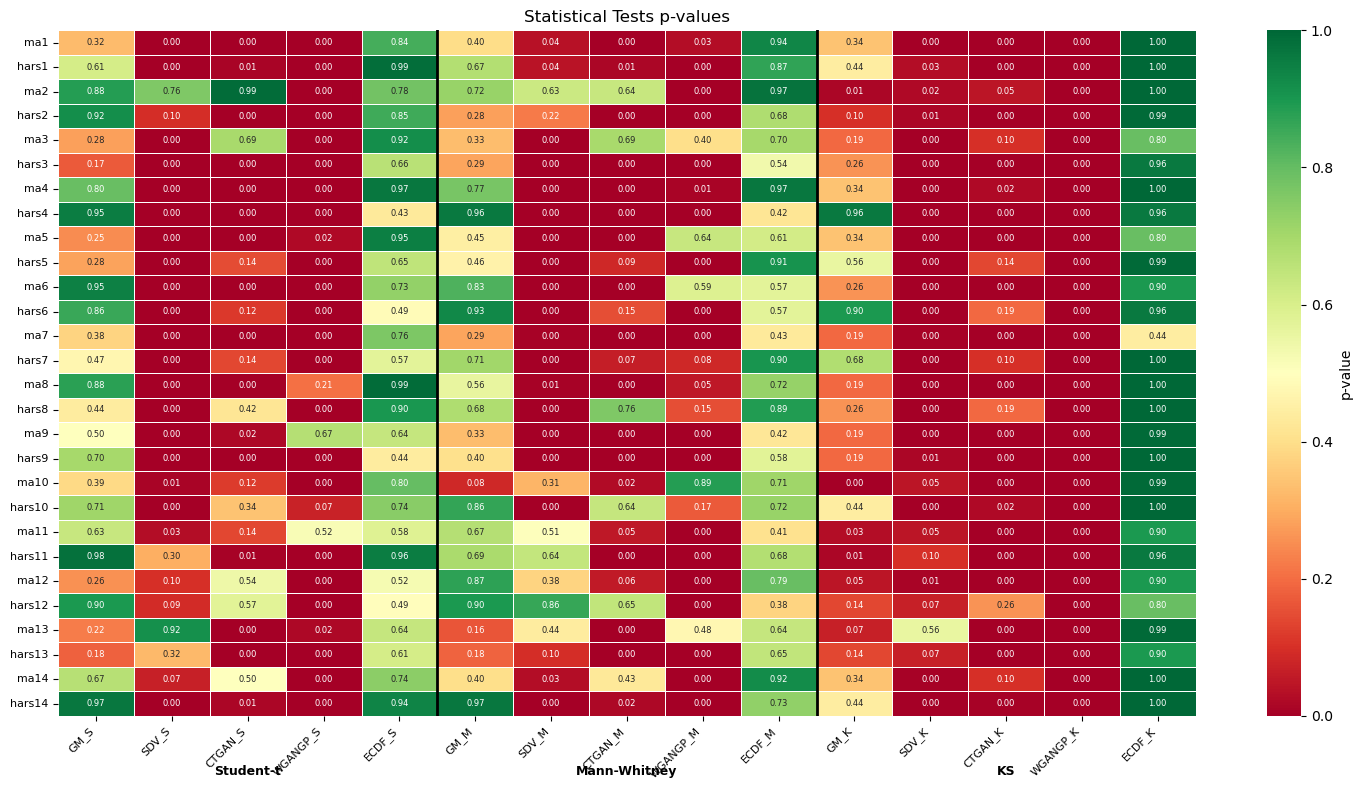

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Statistical test p-value heatmap
fig, ax = plt.subplots(figsize=(15, 8))

# p < 0.05 = red (significant difference), p >= 0.05 = green (no significant difference)
sns.heatmap(df_tests_all, ax=ax,
            cmap='RdYlGn',        # red -> yellow -> green, green = large p = good
            vmin=0, vmax=1,
            linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            cbar_kws={'label': 'p-value'})

# Vertical reference lines separating the 3 tests (5 columns per test)
for x in [5, 10]:
    ax.axvline(x=x, color='black', linewidth=2)

ax.set_title('Statistical Tests p-values', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Label the three test regions
for x, label in zip([2.5, 7.5, 12.5], ['Student-t', 'Mann-Whitney', 'KS']):
    ax.text(x, len(df_tests_all) + 2.0, label,   # data coords, placed below the last row
            ha='center', va='top', fontsize=9, fontweight='bold',
            transform=ax.transData,
            clip_on=False)

fig.tight_layout()
fig.savefig('UNIVARIATE RESEMBLANCE RESULTS/STATISTICAL_TESTS_HEATMAP.svg', bbox_inches='tight')
plt.show()


## 5. Boxplots comparisson
In this part boxplots of each variable are plotted to analyse the statistical properties of each variable.

In [21]:
columns = (data['Real'].select_dtypes(include=['float64','int64'])).columns
len(columns)

28

In [22]:
boxplots_data = dict()
for c in columns :
    boxplots_data[c] = data['Real'][c]
    for name in SYNTHESIZERS :
        boxplots_data[c] = np.column_stack((boxplots_data[c], data[name][c]))

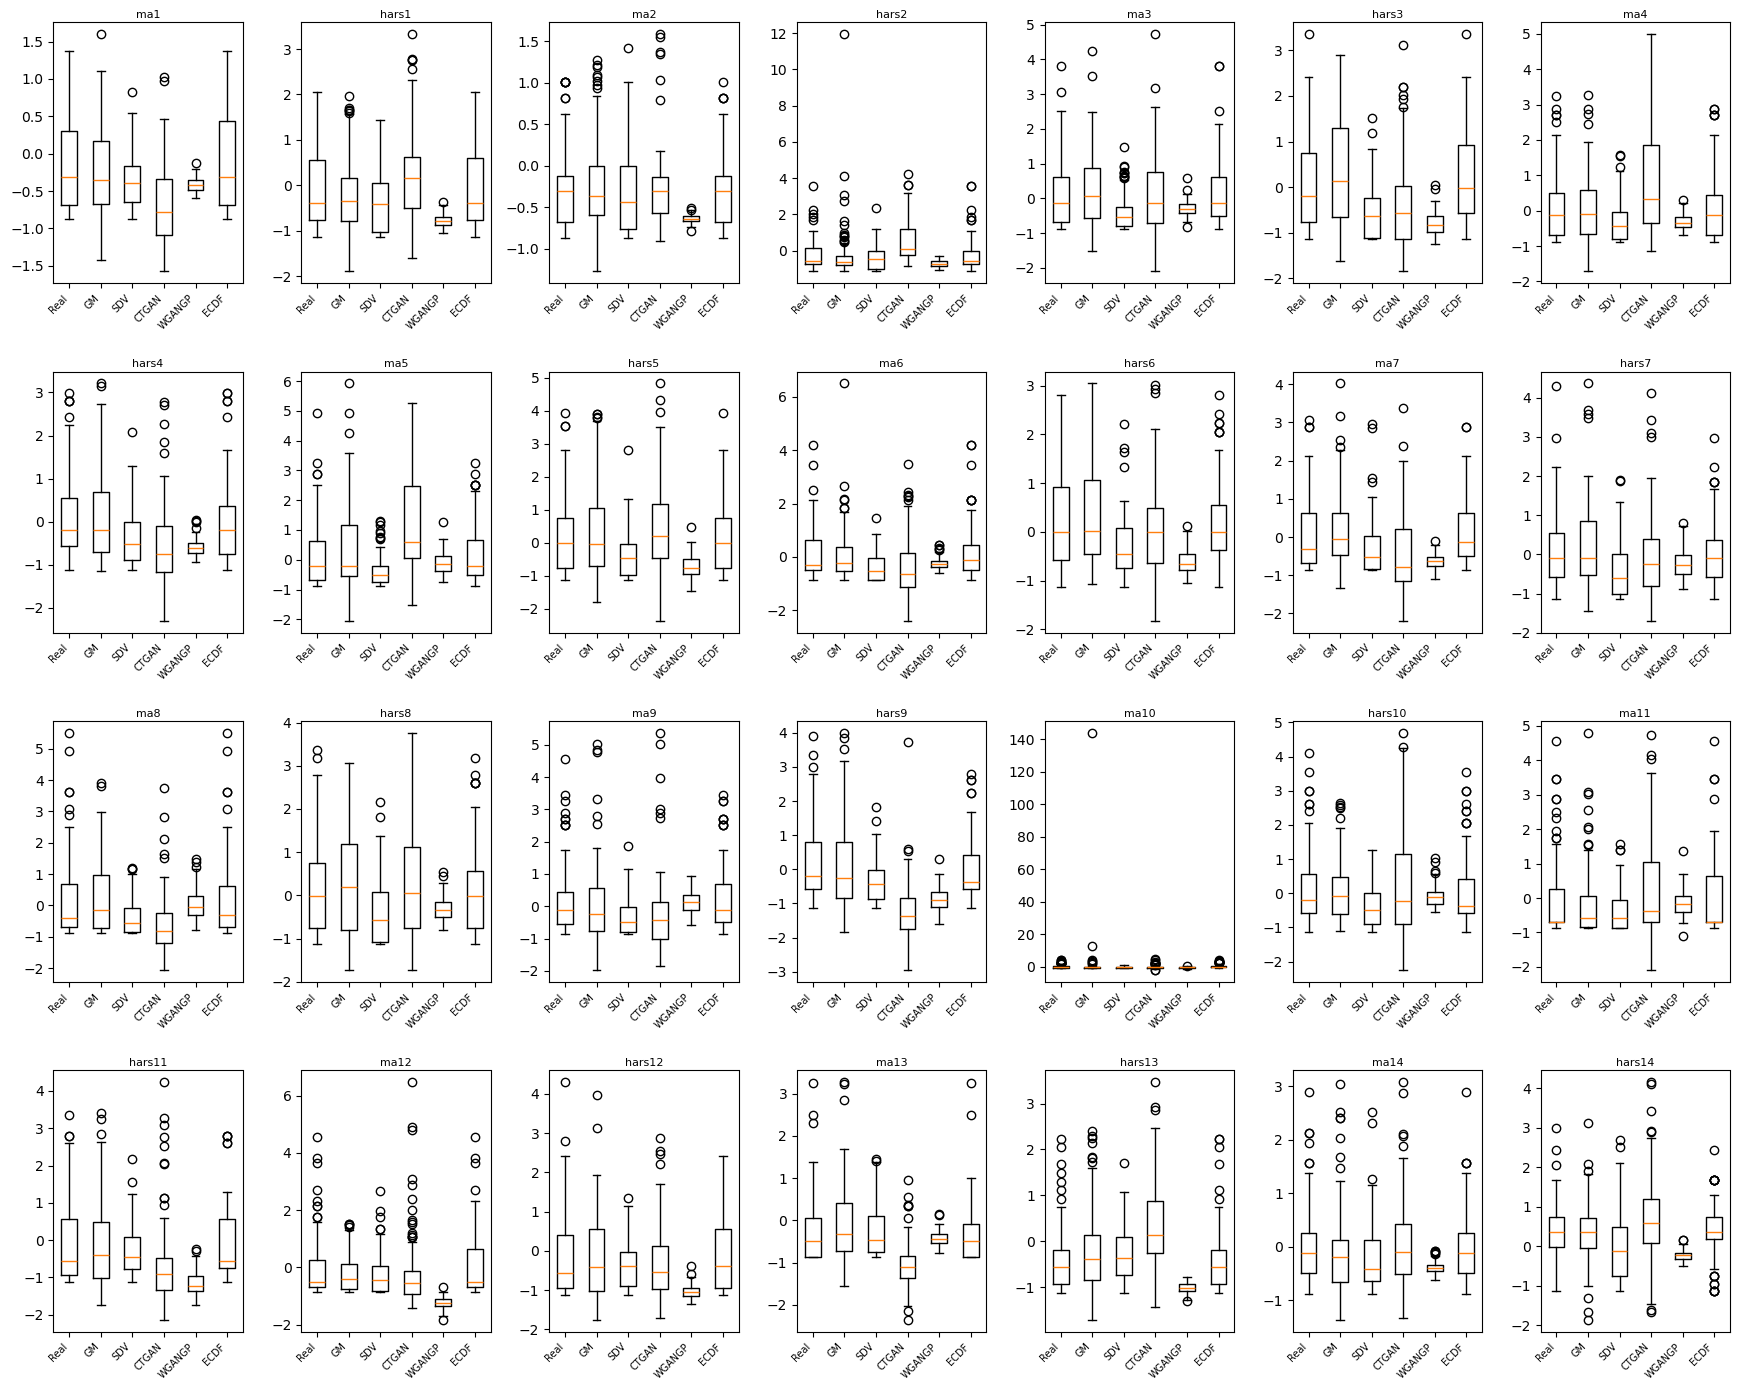

In [23]:
ncols = 7
nrows = int(np.ceil(len(columns) / ncols))

# Auto-generate grid index (no hardcoding)
idx = {i: [i // ncols, i % ncols] for i in range(len(columns))}

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 2.5, nrows * 3.5))

for i in range(len(columns)):
    ax = axs[idx[i][0], idx[i][1]]
    ax.boxplot(boxplots_data[columns[i]])
    ax.set_title(columns[i], fontsize=8, pad=3)        # smaller font, more padding
    ax.set_xticks(range(1, len(DATA_TYPES) + 1))
    ax.set_xticklabels(DATA_TYPES, rotation=45, ha='right', fontsize=7)  # rotated to avoid overlap

# Hide unused subplots (if len(columns) doesn't divide evenly by ncols)
for j in range(len(columns), nrows * ncols):
    axs[j // ncols, j % ncols].set_visible(False)

fig.tight_layout(h_pad=2.0)   # extra row spacing for x-axis labels
fig.savefig('UNIVARIATE RESEMBLANCE RESULTS/BOXPLOTS.svg', bbox_inches='tight')

## 6. Frequency distributions comparisson
In this part histograms of each variable are plotted to compare the frequency distributions.

In [24]:
columns = data['Real'].columns
len(columns)

29

In [25]:
hists_data = dict()
for c in columns :
    hists_data[c] = data['Real'][c]
    for name in SYNTHESIZERS :
        hists_data[c] = np.column_stack((hists_data[c], data[name][c]))

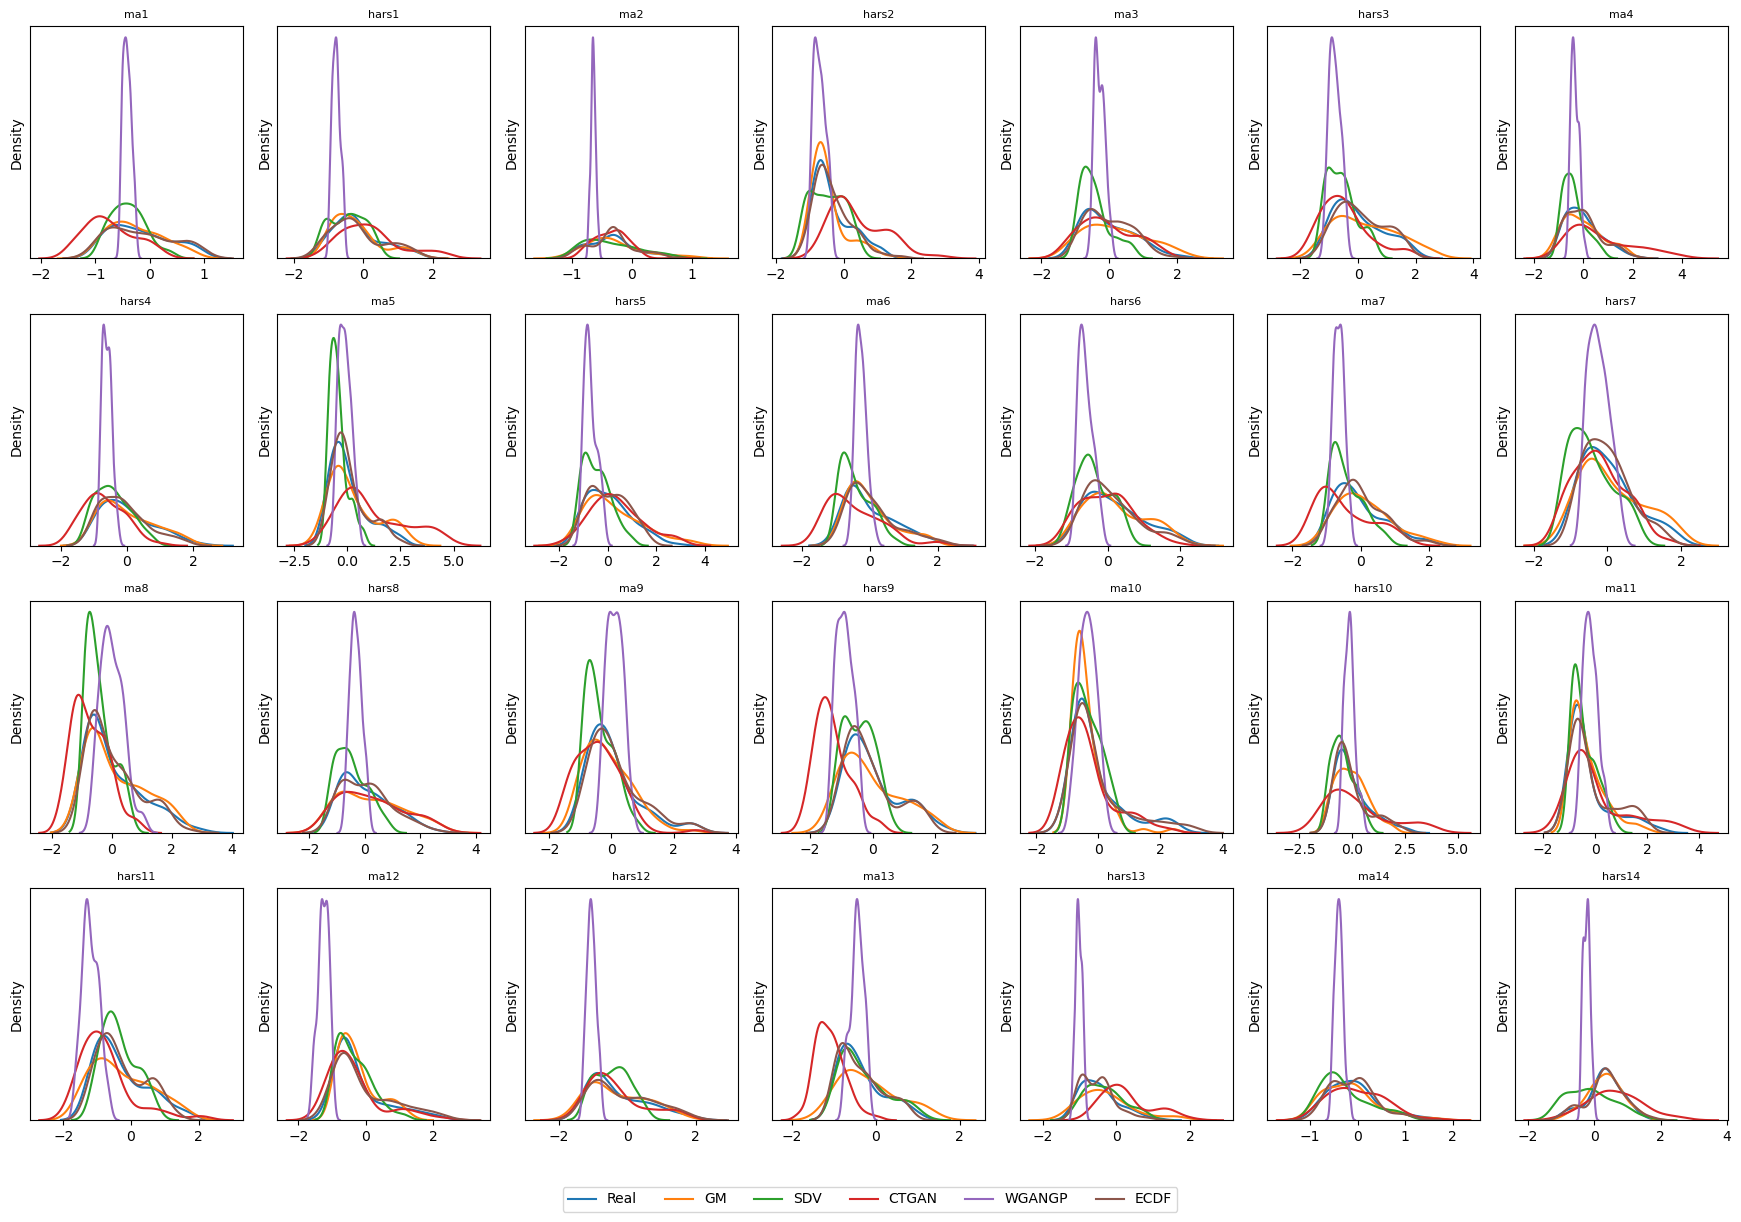

In [26]:
columns = data['Real'].select_dtypes(include=['float64', 'int64']).columns  # numeric columns only

ncols = 7
nrows = int(np.ceil(len(columns) / ncols))
idx = {i: [i // ncols, i % ncols] for i in range(len(columns))}

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 2.5, nrows * 3))

for i in range(len(columns)):
    ax = axs[idx[i][0], idx[i][1]]
    ax.set_title(columns[i], fontsize=8)

    arr = hists_data[columns[i]]
    for col in range(arr.shape[1]):
        arr_col = np.sort(arr[:, col])
        # trim top/bottom 5% extreme values before plotting KDE
        sns.kdeplot(arr_col[int(0.05 * len(arr_col)) : int(0.95 * len(arr_col))], ax=ax)

    ax.set_yticks([])

# Hide unused subplots
for j in range(len(columns), nrows * ncols):
    axs[j // ncols, j % ncols].set_visible(False)

# Place legend outside the grid
handles, _ = axs[0, 0].get_legend_handles_labels()
fig.legend(DATA_TYPES, ncol=len(DATA_TYPES), loc='lower center', bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig('UNIVARIATE RESEMBLANCE RESULTS/HISTOGRAMS.svg', bbox_inches='tight')